In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib
# matplotlib.use('agg')
import matplotlib.pyplot as plt
import os
# from tqdm.notebook import  tqdm
from tqdm import  tqdm
import talib
import datetime
import math
import  mplfinance as mpf

import sys
sys.path.append('../../DataSource/baostock')
import datasource
sys.path.append('../..')
import Utils
# 这个是筛选多少天上涨多少的，
codes = list(datasource.getStockIndustry()['code'])
code = codes[0]
dt = datasource.getData(code)
dt.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,peTTM,pbMRQ,psTTM,pcfNcfTTM,isST
date,,,,,,,,,,,,,,,,,
2010-01-04,sh.600000,64.829140,64.947929,62.839423,62.928515,64.413379,66191338,1.419984e+09,1,0.835129,1,-2.3052,14.435065,2.877081,5.316299,7.091240,0
2010-01-05,sh.600000,63.581855,64.086709,61.740624,63.403671,62.928515,115147943,2.436891e+09,1,1.452808,1,0.7551,14.287342,2.898805,5.178308,7.144784,0
2010-01-06,sh.600000,63.225488,63.255185,62.007900,62.156386,63.403671,96782575,2.034174e+09,1,1.221095,1,-1.9672,14.006279,2.841779,5.076439,7.004231,0
2010-01-07,sh.600000,62.007900,62.483056,60.285458,60.760614,62.156386,85236072,1.761801e+09,1,1.075414,1,-2.2456,13.691757,2.777965,4.962444,6.846945,0
2010-01-08,sh.600000,60.404247,61.770322,60.285458,61.443652,60.760614,65707646,1.349532e+09,1,0.829026,1,1.1241,13.845672,2.809193,5.018229,6.923915,0


In [4]:
# 我要看看上证A股指数跟所有上证A股股票的关系
# 上证A股指数是 sh.000002
sz_a_index = datasource.getData('sh.000002')
sz_a_index.head()

,code,open,high,low,close,preclose,volume,amount,adjustflag,turn,tradestatus,pctChg,peTTM,pbMRQ,psTTM,pcfNcfTTM,isST
date,,,,,,,,,,,,,,,,,
2010-01-04,sh.000002,3450.732,3456.534,3401.843,3402.309,3437.461,10889116100,1.334143e+11,3,0.009559,1,-1.022611,NaN,NaN,NaN,NaN,0
2010-01-05,sh.000002,3413.552,3451.401,3378.821,3442.582,3402.309,12541400300,1.613074e+11,3,0.011008,1,1.183695,NaN,NaN,NaN,NaN,0
2010-01-06,sh.000002,3437.658,3456.937,3411.939,3413.160,3442.582,12302836100,1.576024e+11,3,0.010799,1,-0.854653,NaN,NaN,NaN,NaN,0
2010-01-07,sh.000002,3412.943,3428.522,3331.724,3348.660,3413.160,12803163300,1.567869e+11,3,0.011229,1,-1.889744,NaN,NaN,NaN,NaN,0
2010-01-08,sh.000002,3332.339,3354.987,3302.627,3351.867,3348.660,9781151500,1.213377e+11,3,0.008577,1,0.095771,NaN,NaN,NaN,NaN,0


In [12]:
# 上证所有的股票是以'sh.60'开头的
sz_a_s = datasource.runSql('select date, sum(amount/turn*100) as amout2 from stock_details  where code like "sh.60%" GROUP by date order by date')
sz_a_s['date'] = pd.to_datetime(sz_a_s['date'])
sz_a_s.head()

,date,amout2
0,2010-01-04,1.123689e+13
1,2010-01-05,1.119717e+13
2,2010-01-06,1.127564e+13
3,2010-01-07,1.108761e+13
4,2010-01-08,1.082818e+13


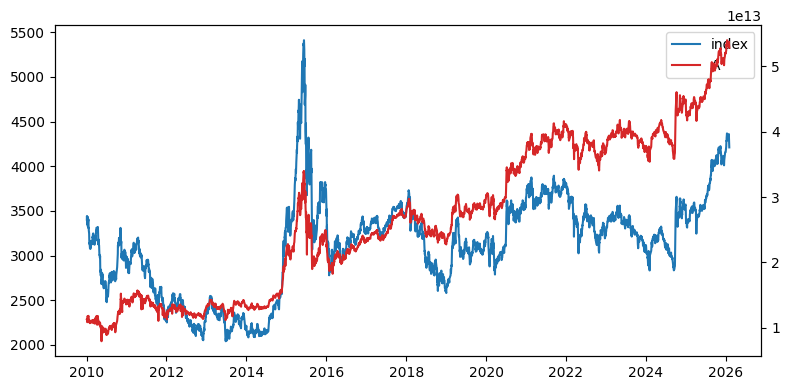

In [13]:
# 然后我期望2个图放在一起。
# 创建画布和第一个轴的实例
fig, ax1 = plt.subplots(figsize=(8, 4))

# 绘制第一条折线（左侧 Y 轴）
ax1.plot(sz_a_index.index, sz_a_index['close'], color='tab:blue', label='index')

# 创建共享 X 轴的第二个 Y 轴
ax2 = ax1.twinx()

ax2.plot(sz_a_s['date'], sz_a_s['amout2'], color='tab:red', label='A')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()

可以看到指数跟市值其实很相似的